# 4. Model Validation

This notebook guides you through selecting and validating climate models (CMIP6 and CORDEX) for use in the attribution study.

---

## How to Use This Notebook

**1. Follow the numbered steps in order.**  
Each section builds upon the previous one, from setup, data loading, and climatology computation, to event analysis and visualization.

**2. Look for <font color="orange"> Orange cells  </font> and code cells marked as <font color="lightgreen">##### (User selection) ##### </font>:** 
| <font color="orange"> Orange cells  </font> | <font color="orange"> Need user intervention </font>|
| ----------- | ----------- |
| <font color="green">**Green cells** </font> | <font color="green">**Run automatically on user input provided in the orange cells and should not be adjusted in most cases** </font>|


**3. Run cells sequentially.**  
Start from the top and execute each cell (`Shift` + `Enter`).  

---

## What This Notebook Does

This notebook helps you:
- Load CMIP6 and CORDEX data (daily mean Tmax, Tmean, Tmin, precipitation)
- Validate models based on:
  - Seasonal cycle shape
  - Climatological spatial pattern
  - Distribution fit parameters
- Decide which models to keep for Step 5 (Attribution)

---


### <font color="green">  **Imports** </font>


In [1]:
# Imports
from c3s_event_attribution_tools import DataClient, Plot, Process, Utils
import requests
import urllib.parse
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import json
import geopandas as gpd
import rasterio
from rasterio import features
from shapely.geometry import shape, Polygon, mapping, MultiPolygon, GeometryCollection
from shapely.vectorized import contains # replace with below
from shapely import contains_xy
import xarray as xr
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.ops import unary_union
from datetime import datetime, timedelta
import pandas as pd
import contextily as ctx
import math
import regionmask
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import cmocean
import base64
from io import BytesIO
import contextily as ctx
from typing import Union, Literal
import os
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from rpy2.robjects.vectors import ListVector
from collections import defaultdict
from pathlib import Path
from scipy.stats import chi2
import xarray as xr
import numpy as np
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
import matplotlib.patches as mpatches
import re


import warnings
warnings.filterwarnings("ignore", category = UserWarning)

from shapely.geometry import Polygon

from aiohttp.client_exceptions import (
    ClientResponseError,
    ClientConnectionError,
    ServerTimeoutError,
    ConnectionTimeoutError,
)
import asyncio
import cartopy.crs as ccrs
import matplotlib.lines as mlines

# import R libraries from WWA
ro.r('''if (!requireNamespace("devtools", quietly = TRUE)) {install.packages("devtools", repos="https://cloud.r-project.org", quiet=TRUE)}''')
ro.r('devtools::install_github("WorldWeatherAttribution/rwwa")')
rwwa = importr("rwwa")
%load_ext rpy2.ipython



Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
R callback write-console: Using GitHub PAT from the git credential store.
  
R callback write-console: Skipping install of 'rwwa' from a github remote, the SHA1 (236d9a6b) has not changed since last install.
  Use `force = TRUE` to force installation
  


### <font color="orange"> User specifications </font>

In [ ]:
# Api key used for the DataClient, replace with your own API key from the C3S Climate Data Store
################# (User selection) ###################
your_api_key = '#######-####-####-####-############'
cordex_arco_token = '#######-####-####-####-############'
######################################################

# Do not touch
CURRENT_DIRECTORY = os.getcwd() 

# Directory you wish to store output files in, using ../ specifies the parent directory
################# (User selection) ###################
your_save_directory = os.path.abspath(os.path.join(CURRENT_DIRECTORY, "../data"))   # change ../data to your desired directory
######################################################

# Create directory if it does not exist
os.makedirs(your_save_directory, exist_ok=True) 

# Initialize DataClient
data_client = DataClient(
    cds_key=your_api_key,
    cordex_arco_token=cordex_arco_token
)

In [3]:
################# (User selection) ###################
# Area of interest bounding box:
# (deg Southern boundary, Western boundary, Northern boundary, Eastern boundary)
bbox = (44, -11, 55, 10)

# Choice of parameter (Tmax, Tmean, Tmin, Precipitation)
parameter = 'Tmean'

# Date of the event
event_end = datetime(2025, 7, 10)
######################################################

bbox = Utils.convert_bbox(*bbox)
CDS_variables = {
    "Tmean": "tas",
    "Tmin": "tasmin",
    "Tmax": "tasmax",
    "Precipitation": "pr",
}
parameter = CDS_variables.get(parameter, parameter)
# Setting up the parameter specific variables
if parameter in ["Tmax", "Tmean", "Tmin", "tas", "tasmin", "tasmax"]:
    variable = "Temperature"
    value_col = "t2m"
    y_label = "c"
    unit = "°C"
    calculation = "absolute"  # absolute or relative
    method = "Mean" 
elif parameter in ["Precipitation", "pr"]:
    variable = "Precipitation"
    value_col = "tp"
    y_label = "mm"
    unit = "mm"
    calculation = "relative"  # absolute or relative
    method = "Total"

# load study region and data from Event Definition step

# study_region = gpd.read_file(r"D:\Git\c3s-451\data\sf_studyregion.shp")
study_region = gpd.read_file(os.path.join(your_save_directory, "sf_studyregion.shp"))

#load observed seasonal cycle data
obs_seasonal_cycle = xr.open_dataset(os.path.join(your_save_directory, "seasonal_cycle_1991-2020.nc"))
#load observed climatology data
obs_climatology = xr.open_dataset(os.path.join(your_save_directory, "climatology_1991-2020.nc"))


## 4a. List of models

In [4]:
import cartopy.crs as ccrs
import matplotlib.lines as mlines

def get_cordex_domain_configs():
    """Returns the raw configuration dictionary for CORDEX domains."""
    return {"SAM" : {"vertices" : {"TLC":(273.26, 18.50), "TRC":(327.52, 17.23), "BRC" :(343.02, -54.6), "BLC" :(254.28, -52.66)},
                    "projection" : ccrs.RotatedPole(pole_longitude = -56.06, pole_latitude = 70.6, central_rotated_longitude=180),
                    "colour" : "red", 
                    "long_name" : "South America"},
           "CAM" : {"vertices" : {"TLC":(235.74, 28.79), "TRC":(337.78, 31.40), "BRC" :(329.46, -17.23), "BLC" :(246.10, -19.46)},
                    "projection" : ccrs.RotatedPole(pole_longitude = 113.98, pole_latitude = 75.74),
                    "colour" : "darkorange", 
                    "long_name" : "Central America"},
           "NAM" : {"vertices" : {"TLC" :(189.26, 59.28), "TRC" :(336.74, 59.28), "BRC": (293.16, 12.55), "BLC" :(232.84, 12.56)},
                    "projection" : ccrs.RotatedPole(pole_longitude = 83.0, pole_latitude = 42.5),
                    "colour" : "forestgreen", 
                    "long_name" : "North America"},
           "EUR" : {"vertices" : {"TLC" :(315.86-360, 60.21), "TRC" :(64.4, 66.65), "BRC" :(36.30, 25.36), "BLC" :(350.01-360, 22.20)},
                    "projection" : ccrs.RotatedPole(pole_longitude = -162.0, pole_latitude = 39.25),
                    "colour" : "royalblue", 
                    "long_name" : "Europe"},
           "AFR" : {"vertices" : {"TLC" :(335.36, 42.24), "TRC" :(60.28, 42.24), "BRC" :(60.28, -45.76), "BLC" :(335.36, -45.76)},
                    "projection" : ccrs.RotatedPole(pole_longitude = 180.0, pole_latitude = 90.0),
                    "colour" : "teal", 
                    "long_name" : "Africa"},
           "WAS" : {"vertices" : {"TLC" :(19.88, 43.5), "TRC" :(115.55, 41.0), "BRC" :(106.43, -15.23), "BLC" :(26.19, -12.97)},
                    "projection" : ccrs.RotatedPole(pole_longitude = 236.66, pole_latitude = 79.95),
                    "colour" : "chocolate",
                    "long_name" : "South Asia"},
           "EAS" : {"vertices" : {"TLC" :(51.59, 50.50), "TRC" :(181.50, 50.31), "BRC" :(156.08, -0.24), "BLC" :(76.91, -0.10)},
                    "projection" : ccrs.RotatedPole(pole_longitude = 296.3, pole_latitude = 61.0),
                    "colour" : "crimson",
                    "long_name" : "East Asia"},
           "CAS" : {"vertices" : {"TLC" :(11.05, 54.76), "TRC" :(139.13, 56.48), "BRC" :(108.44, 19.39), "BLC" :(42.41, 18.34)},
                    "projection" : ccrs.RotatedPole(pole_longitude = 256.61, pole_latitude = 43.48),
                    "colour" : "darkgoldenrod",
                    "long_name" : "Central Asia"},
           "AUS" : {"vertices" : {"TLC" :(110.19, 8.76), "TRC" :(182.02, 12.21), "BRC" :(206.57, -39.25), "BLC" :(89.25, -44.28)},
                    "projection" : ccrs.RotatedPole(pole_longitude = 321.38, pole_latitude = -60.31, central_rotated_longitude=180),
                    "colour" : "deeppink",
                    "long_name" : "Australasia"},
           "ANT" : {"vertices" : {"TLC" :(140.58, -56.0), "TRC" :(245.58, -56.0), "BRC" :(326.14, -56.26), "BLC" :(60.02, -56.26)},
                    "projection" : ccrs.RotatedPole(pole_longitude = 13.09, pole_latitude = -6.08, central_rotated_longitude=180),
                    "colour" : "slategray",
                    "long_name" : "Antarctica"},
           "ARC" : {"vertices" : {"TLC" :(214.68, 55.43), "TRC" :(140.59, 52.53), "BRC" :(40.35, 46.06), "BLC" :(324.82, 52.0)},
                    "projection" : ccrs.RotatedPole(pole_longitude = 0.0, pole_latitude = 6.55),
                    "colour" : "Crimson",
                    "long_name" : "Arctic"},
           "MED" : {"vertices" : {"TLC" :(339.79, 50.65), "TRC" :(50.85, 52.34), "BRC" :(38.33, 26.73), "BLC" :(353.96, 25.63)},
                    "projection" : ccrs.RotatedPole(pole_longitude = 198.0, pole_latitude = 39.25),
                    "colour" : "MediumOrchid",
                    "long_name" : "Mediterranean"},
           "MNA" : {"vertices" : {"TLC" :(333.0, 45.0), "TRC" :(76.0, 45), "BRC" :(76.0, -7), "BLC" :(333.0, -7)},
                    "projection" : ccrs.RotatedPole(pole_longitude = 180.0, pole_latitude = 90.0),
                    "colour" : "MediumSeaGreen",
                    "long_name" : "Middle East / North Africa"},
}






    

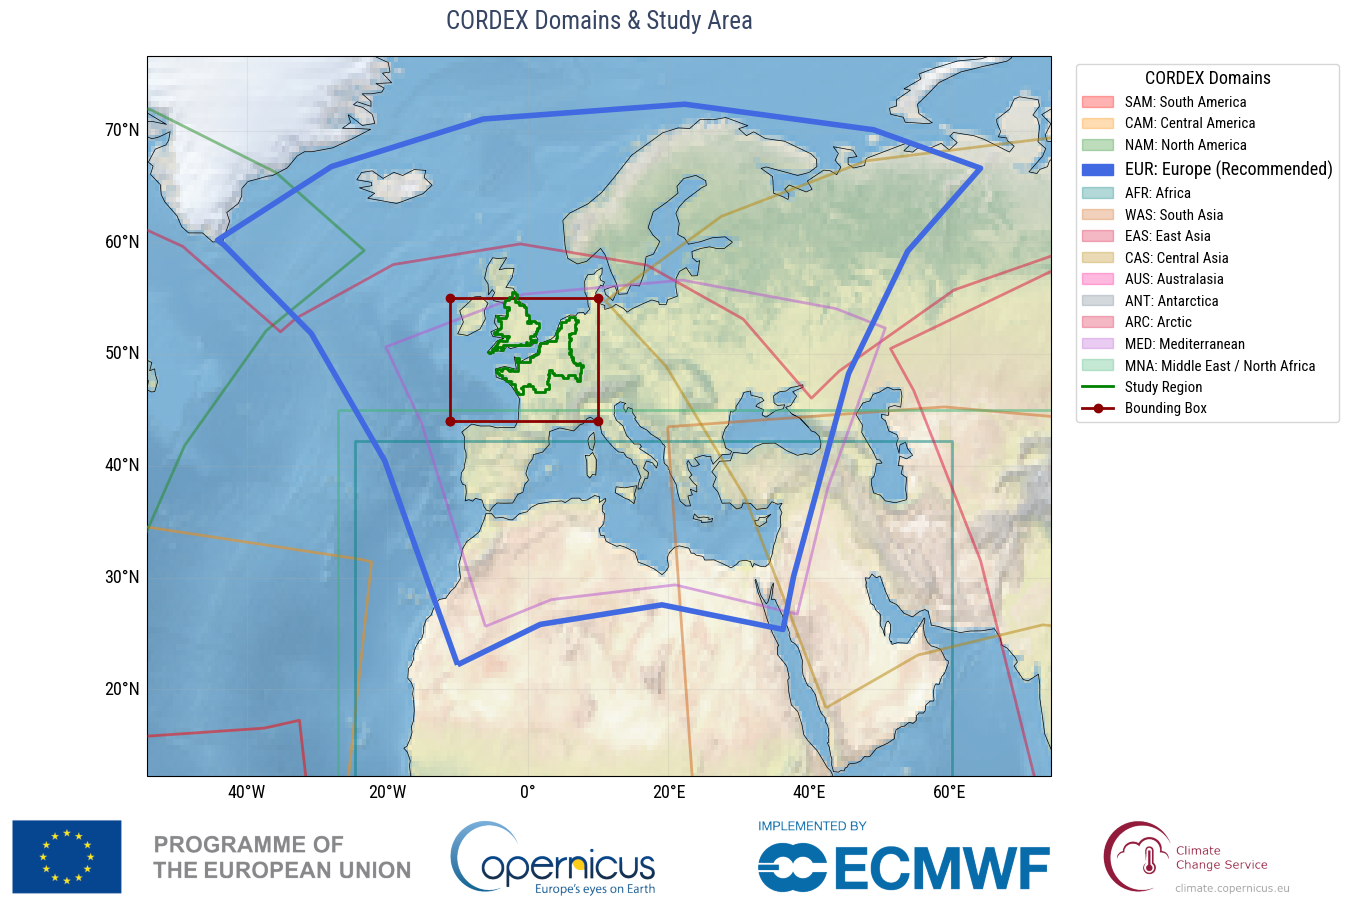

In [5]:
# 1. Init
mapproj = ccrs.PlateCarree()
domains_data = get_cordex_domain_configs()

# 2. Process
gdf = Utils.create_cordex_gdf(domains_data, mapproj)
selected = Utils.find_covering_domain(gdf, study_region, bbox)
print(f"Selected Domain: {selected} ({domains_data[selected]['long_name']})" if selected else "No single domain fully covers the study area.")
# 3. Plot
fig, ax, img_ax = Plot.plot_cordex_map(gdf, domains_data, bbox, study_region, mapproj, selected_domain=selected)


In [35]:
############ (User selection) ####################
#Select the CORDEX domain to use for the analysis 
domain = ["EUR"]
##################################################

catalog_path = Path(f"{your_save_directory}/projections_cordex_domains_single_levels-ZARR-Access-new.txt")
assert catalog_path.exists(), f"Catalog not found: {catalog_path.resolve()}"

cordex_models = Process.build_cordex_model_pairs(catalog_path, domain)
print('Se han encontrado', len(cordex_models), 'modelos CORDEX')

Se han encontrado 58 modelos CORDEX


In [20]:
bbox = (44, -11, 55, 10)
historical_time_range = (datetime(1950, 1, 1), datetime(2006, 12, 31))
future_time_range = (datetime(2006, 1, 1), datetime(2100, 12, 31))



def fetch_and_merge_cordex_data(models, variable_name, bbox, hist_range, fut_range, max_models=None):
    valid_models = []
    dropped_models = []
    for entry in models:
        hist_ds = rcp85_ds = None

        try:
            hist_ds = data_client.fetch_cordex_xr(variable=variable_name, model_url=entry["hist_url"], bbox=bbox, time_range=hist_range)
            rcp85_ds = data_client.fetch_cordex_xr(variable=variable_name, model_url=entry["rcp85_url"], bbox=bbox, time_range=fut_range)
            merged = xr.concat([hist_ds, rcp85_ds], dim="time")
            
            valid_models.append({**entry, "experiment_data": merged})
            if max_models is not None and len(valid_models) >= max_models:
                break

        except KeyError:
            dropped_models.append(entry)

        finally:
            for ds in (hist_ds, rcp85_ds):
                close = getattr(ds, "close", None)
                if callable(close):
                    close()

    return valid_models, dropped_models


cordex_models, cordex_models_dropped = fetch_and_merge_cordex_data(cordex_models, parameter, bbox, historical_time_range, future_time_range, max_models=3)

print(f"Validated {len(cordex_models)} CORDEX models with '{parameter}' available; dropped {len(cordex_models_dropped)}.")

TypeError: string indices must be integers, not 'str'

In [22]:
cordex_models

[{'domain': 'EUR11',
  'gcm': 'cccma_canesm2',
  'rcm': 'clmcom_clm_cclm4_8_17',
  'member': 'r1i1p1',
  'temporal': 'day',
  'res_value': 11,
  'hist_url': 'https://arco.datastores.ecmwf.int/cadl-arco-geo-014/arco/projections_cordex_domains_single_levels/eur11-hist-day-cccma_canesm2-clmcom_clm_cclm4_8_17-r1i1p1/geoChunked.zarr',
  'rcp85_url': 'https://arco.datastores.ecmwf.int/cadl-arco-geo-028/arco/projections_cordex_domains_single_levels/eur11-rcp85-day-cccma_canesm2-clmcom_clm_cclm4_8_17-r1i1p1/geoChunked.zarr'},
 {'domain': 'EUR11',
  'gcm': 'cccma_canesm2',
  'rcm': 'gerics_remo2015',
  'member': 'r1i1p1',
  'temporal': 'day',
  'res_value': 11,
  'hist_url': 'https://arco.datastores.ecmwf.int/cadl-arco-geo-015/arco/projections_cordex_domains_single_levels/eur11-hist-day-cccma_canesm2-gerics_remo2015-r1i1p1/geoChunked.zarr',
  'rcp85_url': 'https://arco.datastores.ecmwf.int/cadl-arco-geo-028/arco/projections_cordex_domains_single_levels/eur11-rcp85-day-cccma_canesm2-gerics_remo2

In [38]:
bbox = (44, -11, 55, 10)
historical_time_range = (datetime(1950, 1, 1), datetime(2006, 12, 31))
future_time_range = (datetime(2006, 1, 1), datetime(2100, 12, 31))


cordex_models, cordex_models_dropped = fetch_climate_scenarios(
    analysis_type='cordex',
    models=cordex_models,
    variable_name=parameter,
    bbox=bbox,
    hist_range=historical_time_range,
    fut_range=future_time_range,
    max_models=3
)


--- Starting CORDEX Processing (Exp: rcp85) ---
Processing: cccma_canesm2_clmcom_clm_cclm4_8_17...
   Fetching CORDEX data from URLs...
<xarray.Dataset> Size: 2GB
Dimensions:    (latitude: 110, longitude: 210, time: 20454)
Coordinates:
  * latitude   (latitude) float64 880B 44.05 44.15 44.25 ... 54.75 54.85 54.95
  * longitude  (longitude) float64 2kB -10.95 -10.85 -10.75 ... 9.75 9.85 9.95
  * time       (time) datetime64[ns] 164kB 1950-01-01 1950-01-02 ... 2005-12-31
Data variables:
    tas        (time, latitude, longitude) float32 2GB dask.array<chunksize=(4224, 3, 16), meta=np.ndarray>
   Fetching CORDEX future data from URLs...
   ⚠️ Skipping GMST: No driving model provided.
   ✅ Success: cccma_canesm2_clmcom_clm_cclm4_8_17
Processing: cccma_canesm2_gerics_remo2015...
   Fetching CORDEX data from URLs...
<xarray.Dataset> Size: 2GB
Dimensions:    (latitude: 110, longitude: 210, time: 20453)
Coordinates:
  * latitude   (latitude) float64 880B 44.05 44.15 44.25 ... 54.75 54.85 54.9

CMIP6

In [ ]:
models = [
    'access_cm2', 'access_esm1_5', 'awi_cm_1_1_mr', 'awi_esm_1_1_lr', 'bcc_csm2_mr',
    'bcc_esm1', 'cams_csm1_0', 'canesm5', 'canesm5_canoe', 'cesm2', 'cesm2_fv2',
    'cesm2_waccm', 'cesm2_waccm_fv2', 'ciesm', 'cmcc_cm2_hr4', 'cmcc_cm2_sr5',
    'cmcc_esm2', 'cnrm_cm6_1', 'cnrm_cm6_1_hr', 'cnrm_esm2_1', 'e3sm_1_0', 'e3sm_1_1',
    'e3sm_1_1_eca', 'ec_earth3', 'ec_earth3_aerchem', 'ec_earth3_cc', 'ec_earth3_veg',
    'ec_earth3_veg_lr', 'fgoals_f3_l', 'fgoals_g3', 'fio_esm_2_0', 'gfdl_esm4', 'giss_e2_1_g',
    'giss_e2_1_h', 'hadgem3_gc31_ll', 'hadgem3_gc31_mm', 'iitm_esm', 'inm_cm4_8', 'inm_cm5_0',
    'ipsl_cm5a2_inca', 'ipsl_cm6a_lr', 'kace_1_0_g', 'kiost_esm', 'mcm_ua_1_0', 'miroc6',
    'miroc_es2h', 'miroc_es2l', 'mpi_esm_1_2_ham', 'mpi_esm1_2_hr', 'mpi_esm1_2_lr',
    'mri_esm2_0', 'nesm3', 'norcpm1', 'noresm2_lm', 'noresm2_mm', 'sam0_unicon',
    'taiesm1', 'ukesm1_0_ll'
]


In [37]:
import xarray as xr
from datetime import datetime

def fetch_climate_scenarios(
    analysis_type,
    models, 
    variable_name, 
    bbox, 
    hist_range=(datetime(1950, 1, 1), datetime(2005, 12, 31)),
    fut_range=(datetime(2006, 1, 1), datetime(2100, 12, 31)),
    temp_res="daily",
    max_models=None
):
    """
    Unified fetcher for CMIP6 and CORDEX data.
    
    Parameters:
    - analysis_type: 'cmip6' or 'cordex'
    - models: 
        If 'cmip6': List of model names (strings).
        If 'cordex': List of dictionaries containing {'hist_url', 'rcp85_url', 'driving_model'}.
    """
    
    results_local = {}
    results_gmst = {}
    processed_count = 0

    # 1. Configuration based on Analysis Type
    if analysis_type == 'cmip6':
        exp_hist = "historical"
        exp_fut  = "ssp585"
        gmst_fetch_fn = data_client.fetch_cmip6_xr  # GMST comes from CMIP6
        
    elif analysis_type == 'cordex':
        exp_hist = "historical"
        exp_fut  = "rcp85"
        gmst_fetch_fn = data_client.fetch_cmip6_xr  # GMST comes from CMIP5 (Driver)
        
    else:
        raise ValueError("analysis_type must be 'cmip6' or 'cordex'")

    print(f"\n--- Starting {analysis_type.upper()} Processing (Exp: {exp_fut}) ---")

    # 2. Main Loop
    for entry in models:
        # Stop if max limit reached
        if max_models and processed_count >= max_models:
            break

        # Determine Model Name and Driving Model (for GMST)
        if analysis_type == 'cmip6':
            model_id = entry # entry is just the string name
            driving_model = entry
        else:
            # For CORDEX, entry is a dict. We need a way to identify the driver for CMIP5 fetch.
            # Assuming the dictionary has a key 'driving_model' or 'model_name'
            gcm = entry.get('gcm', 'UnknownGCM')
            rcm = entry.get('rcm', 'UnknownRCM')
            model_id = f"{gcm}_{rcm}"
            driving_model = None
            # try:
            #     driving_model = entry.get('gcm', 'UnknownGCM') # This MUST match a valid CMIP5 model name

            # except KeyError:
            #     driving_model = None

        try:
            print(f"Processing: {model_id}...")

            # --- A. Fetch Local Variable (The Study Data) ---
            if analysis_type == 'cmip6':
                # CMIP6 Local Fetch
                ds_hist = data_client.fetch_cmip6_xr(
                    variable=variable_name, model=model_id, bbox=bbox,
                    time_range=hist_range, experiment=exp_hist, temporal_resolution=temp_res
                )
                ds_fut = data_client.fetch_cmip6_xr(
                    variable=variable_name, model=model_id, bbox=bbox,
                    time_range=fut_range, experiment=exp_fut, temporal_resolution=temp_res
                )
            else:
                # CORDEX Local Fetch (via URL)
                print(f"   Fetching CORDEX data from URLs...")
                ds_hist = data_client.fetch_cordex_xr(
                    variable=variable_name, model_url=entry["hist_url"], bbox=bbox, time_range=hist_range
                )
                # print if data is empty
                print(ds_hist)

                print(f"   Fetching CORDEX future data from URLs...")
                ds_fut = data_client.fetch_cordex_xr(
                    variable=variable_name, model_url=entry["rcp85_url"], bbox=bbox, time_range=fut_range
                )

            # Merge Local
            local_merged = xr.concat([ds_hist, ds_fut], dim="time", combine_attrs="override")

            # --- B. Fetch Global Mean Surface Temp (GMST) ---
            # This logic is now uniform because we selected the 'gmst_fetch_fn' at the start
            if driving_model is not None:
                print(f"   -> Fetching GMST for {driving_model}...")
                gmst_hist = gmst_fetch_fn(
                    variable='tas', model=driving_model, bbox=(-180, -90, 180, 90),
                    time_range=hist_range, experiment="historical", temporal_resolution="monthly"
                )
                gmst_fut = gmst_fetch_fn(
                    variable='tas', model=driving_model, bbox=(-180, -90, 180, 90),
                    time_range=fut_range, experiment=exp_fut, temporal_resolution="monthly"
                )
                gmst_merged = xr.concat([gmst_hist, gmst_fut], dim="time", combine_attrs="override")
            else:
                # This is what will run for your CORDEX models now
                print(f"   ⚠️ Skipping GMST: No driving model provided.")
                gmst_merged = None

            # --- C. Store Results ---
            results_local[model_id] = local_merged
            if gmst_merged is not None:
                results_gmst[model_id] = gmst_merged
            
            processed_count += 1
            print(f"   ✅ Success: {model_id}")

        except Exception as e:
            print(f"   ❌ Failed {model_id}: {str(e)}")
            continue

    return results_local, results_gmst

In [9]:
GCM_models = [
    'access_cm2', 'canesm5', 'cesm2'
]

future_time_range = (datetime(2015, 1, 1), datetime(2016, 12, 31))
historical_time_range = (datetime(2013, 1, 1), datetime(2014, 12, 31))
experiment = ["ssp5_8_5", "historical"]

CMIP6_models, CMIP6_GMST = fetch_climate_scenarios(
    analysis_type='cmip6',
    models=GCM_models,
    variable_name=parameter,
    bbox=bbox,
    hist_range=historical_time_range,
    fut_range=future_time_range
)


--- Starting CMIP6 Processing (Exp: ssp585) ---
Processing: access_cm2...


2026-01-16 10:50:43,595 INFO Request ID is ac52eb15-c22d-49b5-8bf0-fa0f4c6d568c
2026-01-16 10:50:43,669 INFO status has been updated to accepted
2026-01-16 10:50:52,103 INFO status has been updated to running
2026-01-16 10:51:33,557 INFO status has been updated to successful


2026-01-16 10:51:35,290 INFO Request ID is 93d339f6-84a6-44dd-8a76-bed1baa33ef6
2026-01-16 10:51:35,357 INFO status has been updated to accepted
2026-01-16 10:51:50,098 INFO status has been updated to running
2026-01-16 10:52:26,367 INFO status has been updated to successful
C:\Users\daniel\AppData\Local\Temp\ipykernel_32324\63633774.py:84: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  local_merged = xr.concat([ds_hist, ds_fut], dim="time", combine_attrs="override")


2026-01-16 10:52:28,231 INFO Request ID is f6c29ba8-acfa-4d7f-a9f9-1a5580f132d9
2026-01-16 10:52:28,317 INFO status has been updated to accepted
2026-01-16 10:52:49,486 INFO status has been updated to running
2026-01-16 10:53:18,116 INFO status has been updated to successful


2026-01-16 10:53:20,484 INFO Request ID is d68d5e46-bb30-418e-bfd9-31c9a5671c9b
2026-01-16 10:53:20,552 INFO status has been updated to accepted
2026-01-16 10:53:41,942 INFO status has been updated to running
2026-01-16 10:53:53,405 INFO status has been updated to successful
C:\Users\daniel\AppData\Local\Temp\ipykernel_32324\63633774.py:98: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  gmst_merged = xr.concat([gmst_hist, gmst_fut], dim="time", combine_attrs="override")


...

2026-01-16 10:56:19,535 INFO Request ID is c0b8237c-bb61-41f8-8f93-be68d09360f5
2026-01-16 10:56:19,947 INFO status has been updated to accepted
2026-01-16 10:56:33,503 INFO status has been updated to running
2026-01-16 10:56:52,652 INFO status has been updated to successful


2026-01-16 10:56:54,610 INFO Request ID is 6acfba49-59ba-4766-b1c1-a74e02a4d45b
2026-01-16 10:56:54,736 INFO status has been updated to accepted
2026-01-16 10:57:03,533 INFO status has been updated to running
2026-01-16 10:57:28,483 INFO status has been updated to successful
C:\Users\daniel\AppData\Local\Temp\ipykernel_32324\63633774.py:84: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  local_merged = xr.concat([ds_hist, ds_fut], dim="time", combine_attrs="override")


2026-01-16 10:57:30,266 INFO Request ID is 8cc56298-b6d9-4d2d-9cf2-d823892324c0
2026-01-16 10:57:30,340 INFO status has been updated to accepted
2026-01-16 10:57:43,872 INFO status has been updated to running
2026-01-16 10:58:03,057 INFO status has been updated to successful


2026-01-16 10:58:05,208 INFO Request ID is 1e996bce-2585-4658-b9a3-fc18c7414e17
2026-01-16 10:58:05,270 INFO status has been updated to accepted
2026-01-16 10:58:18,858 INFO status has been updated to running
2026-01-16 10:58:37,959 INFO status has been updated to successful
C:\Users\daniel\AppData\Local\Temp\ipykernel_32324\63633774.py:98: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  gmst_merged = xr.concat([gmst_hist, gmst_fut], dim="time", combine_attrs="override")


   ✅ Success: cesm2


In [16]:
GCM_models = [
    'access_cm2', 'canesm5', 'cesm2'
]

future_time_range = (datetime(2015, 1, 1), datetime(2100, 12, 31))
historical_time_range = (datetime(1850, 1, 1), datetime(2014, 12, 31))
experiment = ["ssp5_8_5", "historical"]

CMIP6_models, CMIP6_GMST = fetch_and_merge_cmip6_data(
    models=GCM_models,
    variable_name=parameter,
    bbox=bbox,
    hist_range=historical_time_range,
    fut_range=future_time_range,
    experiments=experiment
)

--- Processing CMIP6 model: access_cm2 ---
Using locally cached CMIP6 data from CDS.
Using locally cached CMIP6 data from CDS.
Using locally cached CMIP6 data from CDS.
Using locally cached CMIP6 data from CDS.


C:\Users\daniel\AppData\Local\Temp\ipykernel_32892\3566359136.py:46: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  merged_gmst = xr.concat([gmst_hist, gmst_future], dim="time", combine_attrs="override")


Successfully merged access_cm2
--- Processing CMIP6 model: canesm5 ---


2026-01-15 09:27:03,678 INFO Request ID is 5bbfb37a-5244-4844-b7ca-859abeda8782
2026-01-15 09:27:03,739 INFO status has been updated to accepted
2026-01-15 09:27:12,472 INFO status has been updated to running
2026-01-15 09:28:58,071 INFO status has been updated to successful


2026-01-15 09:29:01,636 INFO Request ID is 062c2b12-0aa6-4eb6-9216-81b1e4291793
2026-01-15 09:29:01,708 INFO status has been updated to accepted
2026-01-15 09:29:15,920 INFO status has been updated to running
2026-01-15 09:31:54,361 INFO status has been updated to successful


...

2026-01-15 09:33:06,740 INFO Request ID is 437e0d86-3dbb-4c3d-a96c-eeebc12cdb60
2026-01-15 09:33:06,803 INFO status has been updated to accepted
2026-01-15 09:33:28,259 INFO status has been updated to running
2026-01-15 09:45:27,027 INFO status has been updated to successful


2026-01-15 09:45:35,315 INFO Request ID is 6647b9cd-f0ea-4457-b5ed-7f09386a94ce
2026-01-15 09:45:35,517 INFO status has been updated to accepted
2026-01-15 09:45:44,178 INFO status has been updated to running
2026-01-15 10:03:56,409 INFO status has been updated to successful


2026-01-15 10:04:12,671 INFO Request ID is 7e6e8f7f-78bf-4ea0-8510-7bce0e521ce6
2026-01-15 10:04:12,736 INFO status has been updated to accepted
2026-01-15 10:04:26,273 INFO status has been updated to running
2026-01-15 10:05:28,289 INFO status has been updated to successful


2026-01-15 10:06:34,528 INFO Request ID is 9d6fdc5f-b96a-4bb4-824e-06e1a9802597
2026-01-15 10:06:34,601 INFO status has been updated to accepted
2026-01-15 10:06:48,240 INFO status has been updated to running
2026-01-15 10:07:24,538 INFO status has been updated to successful


Successfully merged cesm2


In [ ]:
import xarray as xr
from datetime import datetime

def fetch_and_merge_cmip6_data(models, variable_name, bbox, 
    hist_range=(datetime(1850, 1, 1), datetime(2014, 12, 31)),
    fut_range=(datetime(2015, 1, 1), datetime(2100, 12, 31)),
    experiments=("ssp585", "historical"),
    temp_res="daily",
    max_models=None
):
    """
    Fetches historical and future CMIP6 data for a list of models, 
    merges them along the time dimension, and also fetches Global Mean Surface Temp (GMST).
    """
    cmip6_models = {}
    cmip6_gmst = {}
    processed_models = []

    for model in models:
        try:
            print(f"--- Processing CMIP6 model: {model} ---")
            
            # Fetch Localized Variable (Daily)
            future_ds = data_client.fetch_cmip6_xr(variable=variable_name, model=model, bbox=bbox,
                time_range=fut_range, experiment=experiments[0], temporal_resolution=temp_res
            )
            
            hist_ds = data_client.fetch_cmip6_xr( variable=variable_name, model=model, bbox=bbox, 
                time_range=hist_range, experiment=experiments[1], temporal_resolution=temp_res
            )

            # Fetch Global TAS (Monthly) for GMST
            gmst_hist = data_client.fetch_cmip6_xr(variable='tas', model=model, bbox=(-180, -90, 180, 90),
                time_range=hist_range, experiment="historical", temporal_resolution="monthly"
            )
            
            gmst_future = data_client.fetch_cmip6_xr( variable='tas', model=model, bbox=(-180, -90, 180, 90),
                time_range=fut_range, experiment=experiments[0], temporal_resolution="monthly"
            )

            # Merge Datasets
            merged_local = xr.concat([hist_ds, future_ds], dim="time", combine_attrs="override")
            merged_gmst = xr.concat([gmst_hist, gmst_future], dim="time", combine_attrs="override")

            # Store in dictionaries
            cmip6_models[model] = merged_local
            cmip6_gmst[model] = merged_gmst
            processed_models.append(model)
            if max_models is not None and len(processed_models) >= max_models:
                break
            
            print(f"Successfully merged {model}")

        except Exception as e:
            print(f"⚠️ Failed to process model {model}: {e}")

    return cmip6_models, cmip6_gmst

CORDEX


---

## 4b. Model Validation Procedure

### 4.1 General Properties

a.	Model resolution vs event spatial scale. Is the resolution of the model sufficient to represent the event and for comparison with observations? 
i.	For precipitation, in case of convective precipitation events: 
1.a.i.1.	If the event is large scale but convection is clearly present, omit CMIP6 and use only CORDEX
1.a.i.2.	 If the event is large scale but convection plays a major role (e.g. organised convection in thunderstorms), no attribution possible without convection permitting models and we can’t use CMIP6 or CORDEX.
ii.	For precipitation, if the event happens close to an orographic barrier, omit CMIP6.
iii.	Else, use both CORDEX and CMIP6


In [15]:
# Decide over using CMIP6 or/and CORDEX data



b. Seasonal Cycle

b.	Does the model seasonal cycle resemble the observed seasonal cycle? Calculate and plot model seasonal cycles (years same as in observations) and overlay with observed seasonal cycle. Compare figures of seasonal cycle calculated by e.g. simple averages, especially for precipitation, expert judgement. 
i.	E.g. Do the peaks in the model seasonal cycle correspond to the peaks in observations (in timing)? 
ii.	Note seasonal cycle as “good” (peaks resemble the observed peaks), “reasonable” (peaks resemble most important features but there are some differences) or “bad” (peaks do not resemble observed peaks). Expert judgement.
iii.	Write findings and decisions in table.


In [11]:
import regionmask
import xarray as xr

def compute_climate_indices(data_input, parameter, study_region, 
                            baseline_range=("1990", "2020")):
    """
    Unified processor for CMIP6 and CORDEX data.
    data_input: Can be a dict {name: ds} (CMIP6) or a list of dicts (CORDEX).
    """
    results = {
        "seasonal_cycles": {},
        "spatial_maps": {},
        "time_series": {},
        "processed": [],
        "dropped": []
    }

    # 1. Normalize input to a common format: a list of (label, dataset, entry_metadata)
    items_to_process = []
    if isinstance(data_input, dict):
        # Format for CMIP6
        for name, ds in data_input.items():
            items_to_process.append((name, ds, name))
    else:
        # Format for CORDEX
        for entry in data_input:
            label = f"{entry['gcm']}\n{entry['rcm']}"
            items_to_process.append((label, entry["experiment_data"], entry))

    for label, ds, original_entry in items_to_process:
        print(f"Processing: {label}")
        try:
            # 2. Extract Variable & Unit Conversion
            da = ds[parameter]
            da = Utils.wrap_lon(da)
            da = da - 273.15 # Using the utility function we discussed!

            # 3. Handle Dimensions & Coordinate Names
            # Rename CMIP6-style coords to standard names
            if "lat" in da.coords: da = da.rename({"lat": "latitude"})
            if "lon" in da.coords: da = da.rename({"lon": "longitude"})
            
            # Detect spatial dimensions for averaging (Native Grid Handling)
            if "rlon" in da.dims:
                xdim, ydim = ["rlon", "rlat"]
            elif "x" in da.dims:
                xdim, ydim = ["x", "y"]
            else:
                xdim, ydim = ["longitude", "latitude"]

            da = da.sortby("time")

            # 4. Product A: Spatial Climatology
            da_clim = da.sel(time=slice(*baseline_range)).mean("time")

            # 5. Spatial Masking
            mask = regionmask.mask_geopandas(study_region, da.longitude, da.latitude)
            ts_regional = da.where(mask == 0, drop=True)

            # 6. Product B: Regional Time Series (Latitude Weighted)
            ts_weighted = Process.weighted_values(ts_regional, value_col=None, lat_col='latitude')
            ts_final = ts_weighted.mean([xdim, ydim]).sortby("time")

            # 7. Product C: Seasonal Cycle
            sc = ts_final.sel(time=slice(*baseline_range)).groupby("time.dayofyear").mean()

            # 8. Store Results
            results["seasonal_cycles"][label] = sc.compute()
            results["spatial_maps"][label] = da_clim.compute()
            results["time_series"][label] = ts_final.compute()
            results["processed"].append(original_entry)
            
            print(f"✅ Success")

        except Exception as exc:
            results["dropped"].append(original_entry)
            print(f"❌ Failed: {exc}")
            continue

    return results

In [39]:
CORDEX_analysis = compute_climate_indices(
    data_input=cordex_models,
    parameter=parameter,
    study_region=study_region,
    baseline_range=("1990", "2020")
)

Processing: cccma_canesm2_clmcom_clm_cclm4_8_17
✅ Success
Processing: cccma_canesm2_gerics_remo2015
✅ Success
Processing: cnrm_cerfacs_cm5_clmcom_eth_cosmo_crclim
✅ Success


In [41]:
CORDEX_analysis

{'seasonal_cycles': {'cccma_canesm2_clmcom_clm_cclm4_8_17': <xarray.DataArray 'tas' (dayofyear: 366)> Size: 3kB
  array([ 5.08858402,  4.6621997 ,  4.59963396,  4.5315159 ,  4.51275625,
          4.3397359 ,  4.65556821,  4.40554432,  3.45319459,  3.26098123,
          4.02214675,  4.42184094,  4.07092409,  3.7100477 ,  3.77827124,
          3.95984207,  4.24038194,  4.24035054,  4.22263238,  4.3238354 ,
          4.0980785 ,  4.66225027,  4.95688643,  4.90022822,  5.21150525,
          4.70877482,  4.23771805,  4.08629864,  4.20658757,  4.25189663,
          4.43051112,  4.51866469,  5.18228094,  4.98752163,  4.29014441,
          4.20512201,  4.19523034,  4.06373719,  4.14737252,  3.7687259 ,
          3.2573043 ,  3.53568817,  3.85853088,  3.43007135,  3.21923796,
          3.38164551,  3.59109421,  4.15160361,  4.14664115,  4.35429398,
          4.52934669,  4.68089351,  4.94403133,  4.77871576,  4.18249401,
          4.31290661,  4.90556844,  5.14018655,  5.02674784,  4.54644359,


In [12]:
CMIP6_analysis = compute_climate_indices(
    data_input=CMIP6_models,
    parameter="tas",
    study_region=study_region,
    baseline_range=("1990", "2020") # Standard 30-year climatology
)

Processing: access_cm2
✅ Success
Processing: canesm5
✅ Success
Processing: cesm2
✅ Success


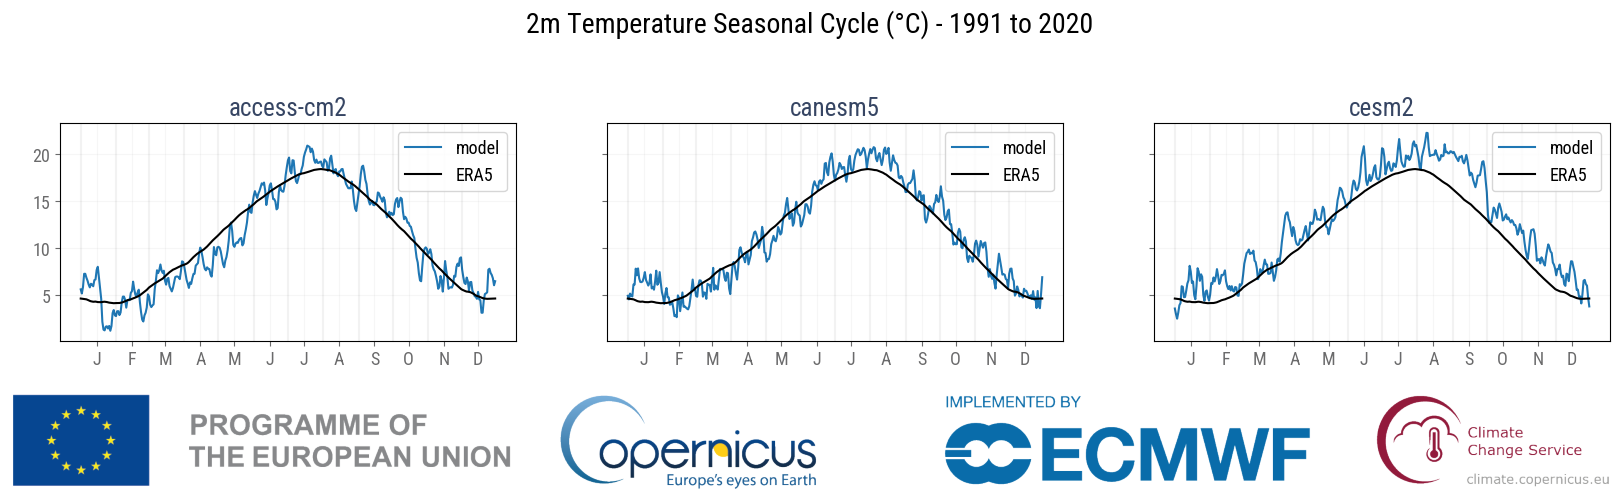

In [13]:
title = "2m Temperature Seasonal Cycle (°C) - 1991 to 2020"
fig, ax, img_ax = Plot.plot_seasonal_cycles(CMIP6_analysis["seasonal_cycles"], obs_seasonal_cycle, value_col=value_col, legend_title=title)

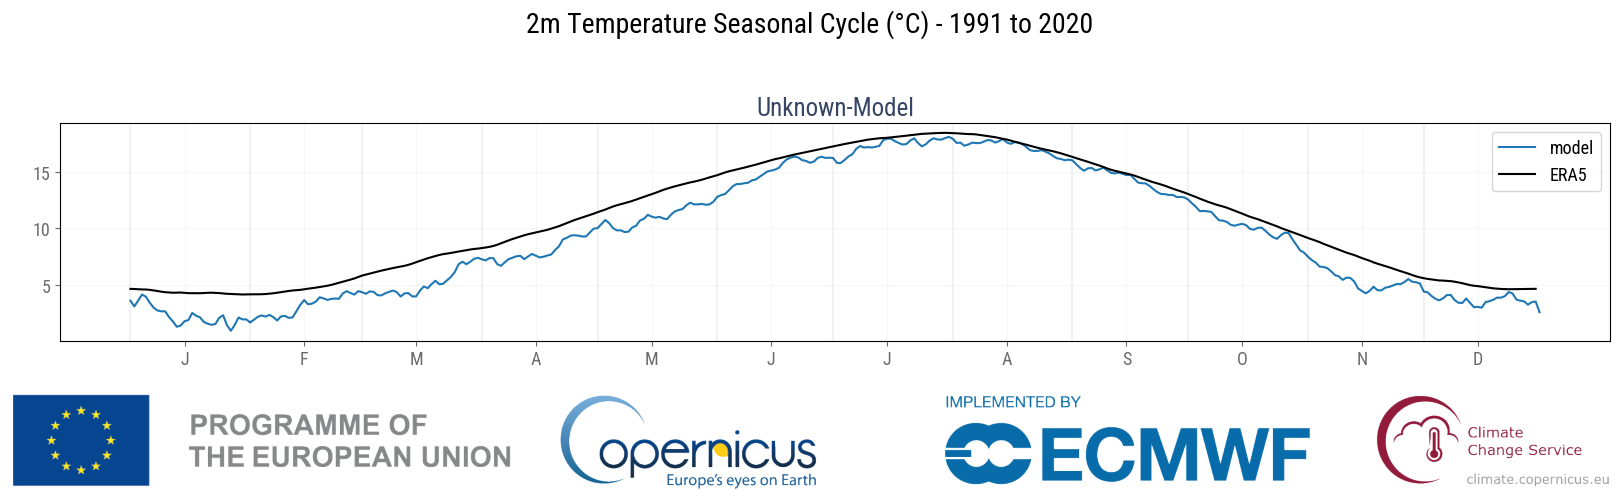

In [13]:
title = "2m Temperature Seasonal Cycle (°C) - 1991 to 2020"
fig, ax, img_ax = Plot.plot_seasonal_cycles(CORDEX_analysis["seasonal_cycles"], obs_seasonal_cycle, value_col=value_col, legend_title=title)

c.	Does the model climatology - the spatial pattern of the variable (e.g. mean temperature over 1991-2020) - resemble the observed spatial pattern? Calculate and plot model spatial patterns and observed spatial pattern and compare figures, expert judgement. Use the same years as in observations. 
i.	Note as “good” (main peaks and troughs overlapping in location with observed peaks and troughs, and relative amplitudes of features are ok), “reasonable” (most of the main features are captured) or “bad” (few of the main features are captured). 
ii.	Write findings and decisions in table.


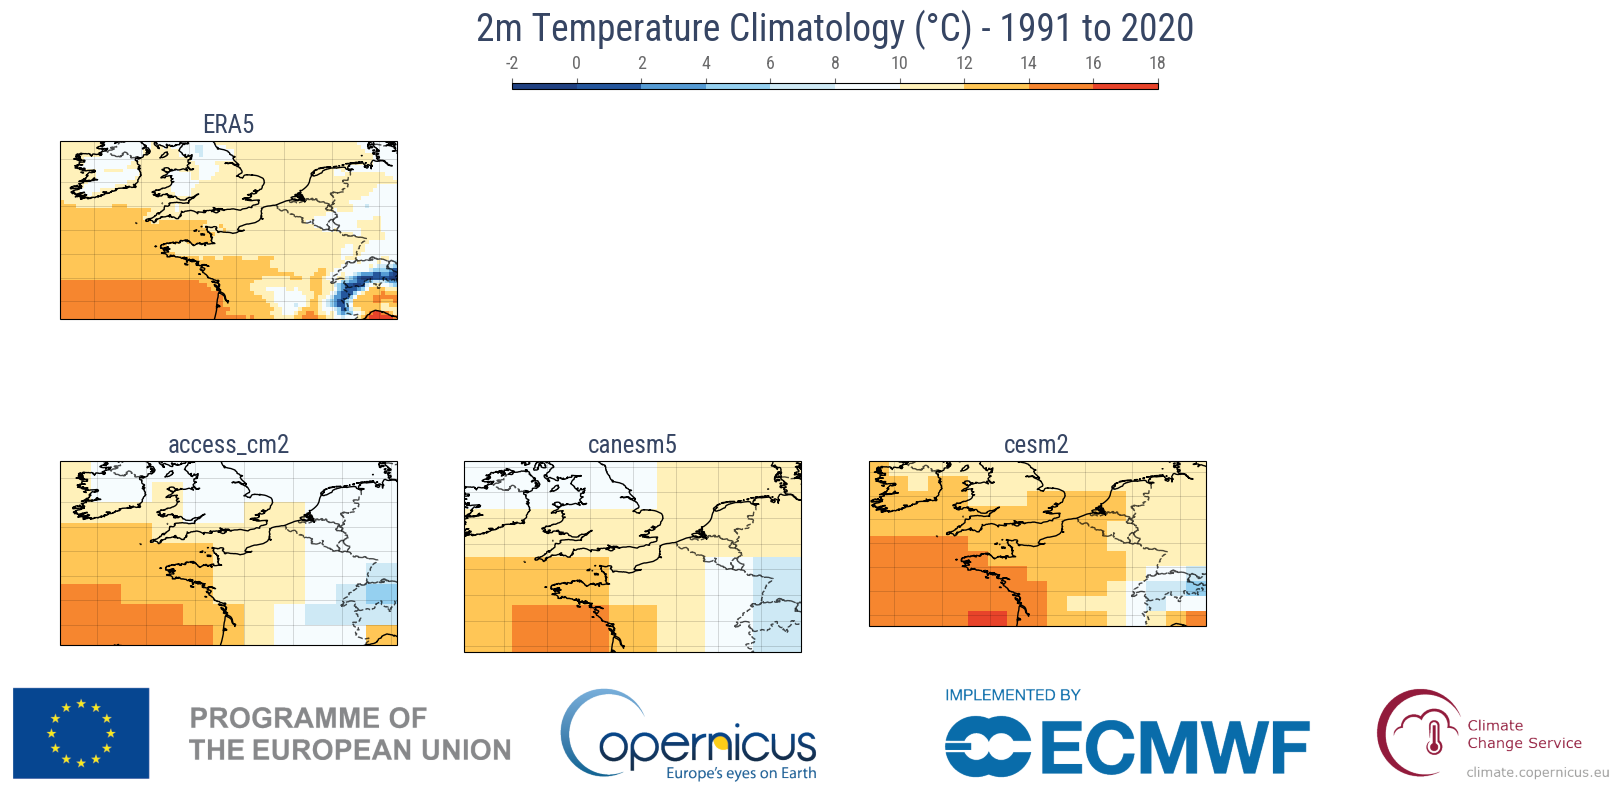

In [46]:

title = "2m Temperature Climatology (°C) - 1991 to 2020"
fig, axs, img_ax = Plot.plot_spatial_maps(obs_climatology[value_col], CMIP6_analysis["spatial_maps"], value_col=value_col, legend_title=title)

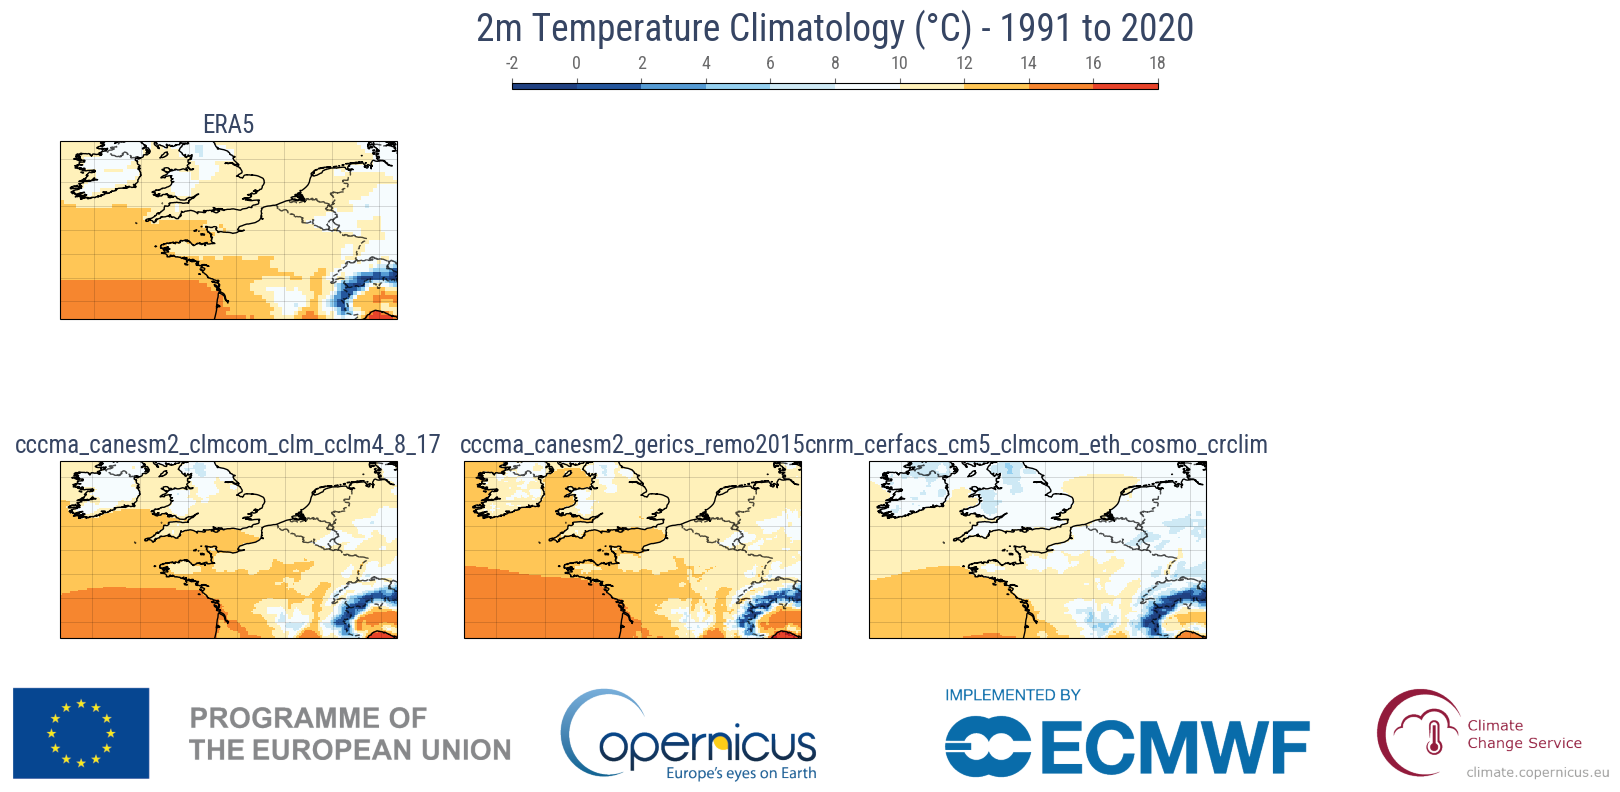

In [40]:

title = "2m Temperature Climatology (°C) - 1991 to 2020"
fig, axs, img_ax = Plot.plot_spatial_maps(obs_climatology[value_col], CORDEX_analysis["spatial_maps"], value_col=value_col, legend_title=title)

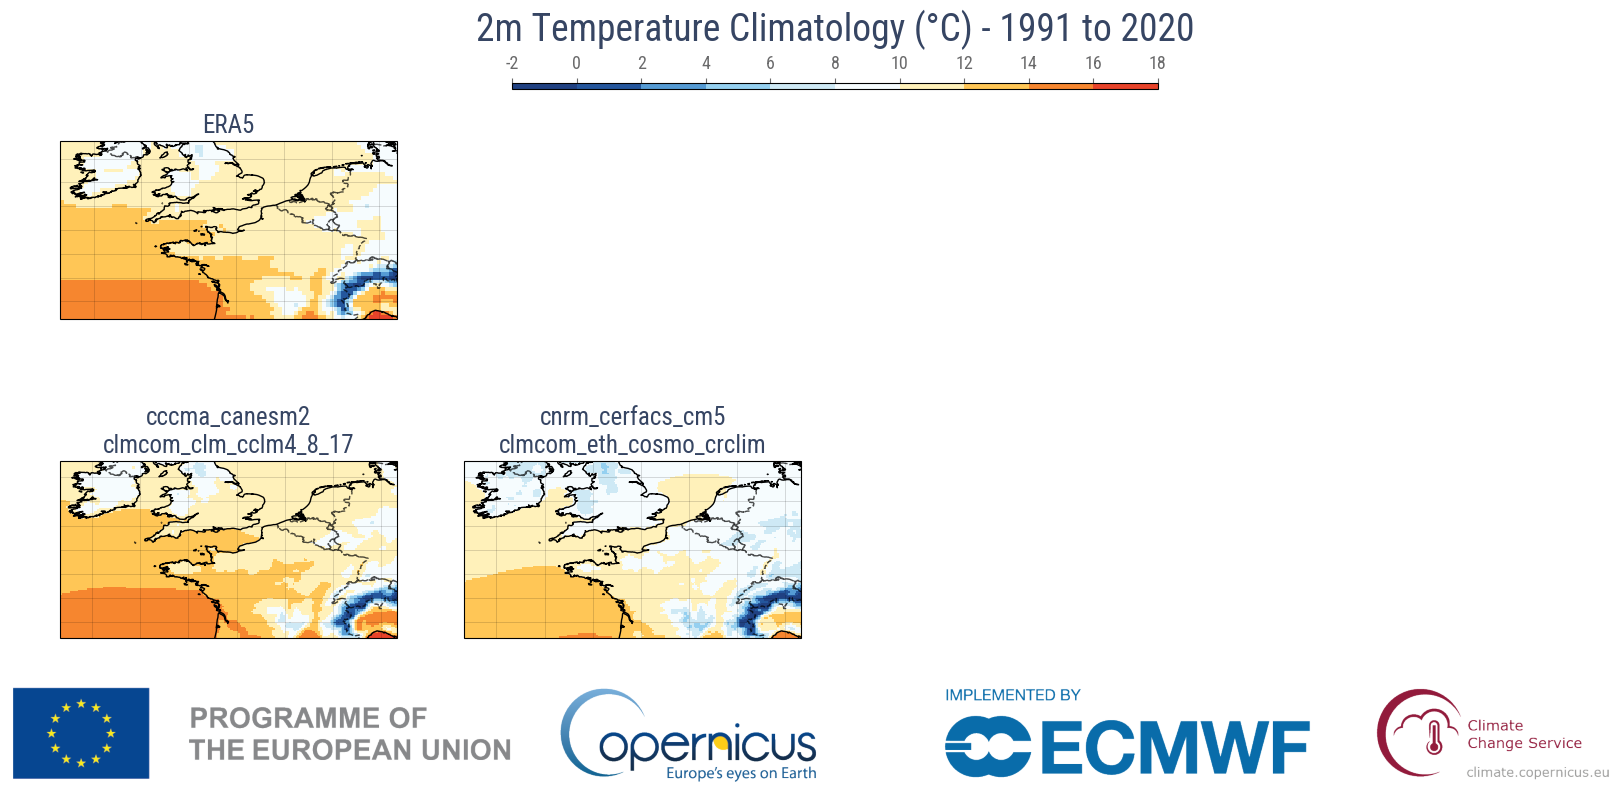

In [47]:

title = "2m Temperature Climatology (°C) - 1991 to 2020"
fig, axs, img_ax = Plot.plot_spatial_maps(obs_climatology[value_col], CORDEX_analysis["spatial_maps"], value_col=value_col, legend_title=title)

d.	If necessary, exclude model runs that require a large bias correction resulting in the event magnitude at the event return period being very different, e.g. an order of magnitude different, to the observed. This is problematic, for example, for event temperatures around 0 ℃ (because of the model physics linked to change of state), or very low (>2x too low) precipitation values etc.  see Step 5.1e.
i.	Write findings and decisions in table (comments).


### 4.2 Decide on model ensembles

4.2	Decide on the model ensembles (CMIP6, which regional CORDEX domain), are considered further for analysis, write down in the scientific report Section 2.2.

### 4.3 Model Time Series

4.3	Calculate the model time series over the same event definition as for observations 
a.	Calculate area average to obtain the annual time series
b.	Calculate the temporal average to obtain the annual time series
c.	Save all model time series


In [48]:
################### User Selection  ##################
# Choose mean, max, min
yearly_value = 'max'

# Padding >= 1 : rolling window, n-days (centered)
padding = 3

# Choose month range, e.g. (1, 12) or (12, 1), .. This is still missing in all model validation script!!!!
month_range = (1, 12)

# Standard method for temperature: mean and for precipitation: sum, if not specified
# If you want to change it, specify here
method = 'mean'
#######################################################

In [50]:

cordex_yearly_series = Process.calculate_yearly_statistics(
    time_series=CORDEX_analysis['time_series'], 
    yearly_value=yearly_value, 
    padding=padding
)

cmip6_yearly_series = Process.calculate_yearly_statistics(
    time_series=CMIP6_analysis['time_series'], 
    yearly_value=yearly_value, 
    padding=padding
)

### 4.4 Model GMST (4-year smoothed)

CMIP6

In [105]:
# Assuming CMIP6_GMST is your dictionary of global 'tas' datasets
event_year = 2025

cmip6_gmst_yearly = compute_gmst_anomalies(
    gmst_dict=CMIP6_GMST,
    event_year=event_year,
    year_range=(1850, 2100)
)

Calculating GMST anomalies for: access_cm2
✅ GMST anomaly calculated (Ref 2025: 15.21°C)
Calculating GMST anomalies for: canesm5
✅ GMST anomaly calculated (Ref 2025: 15.63°C)
Calculating GMST anomalies for: cesm2
✅ GMST anomaly calculated (Ref 2025: 15.52°C)


In [106]:
cmip6_gmst_yearly

{'access_cm2':      year      gmst
 0    1850 -1.351802
 1    1851 -1.297701
 2    1852 -1.296549
 3    1853 -1.263133
 4    1854 -1.289321
 ..    ...       ...
 246  2096  4.421639
 247  2097  4.502070
 248  2098  4.586097
 249  2099  4.658421
 250  2100  4.725940
 
 [251 rows x 2 columns],
 'canesm5':      year      gmst
 0    1850 -2.102440
 1    1851 -2.121288
 2    1852 -2.092112
 3    1853 -2.134157
 4    1854 -2.125124
 ..    ...       ...
 246  2096  5.346399
 247  2097  5.396538
 248  2098  5.489095
 249  2099  5.532860
 250  2100  5.576683
 
 [251 rows x 2 columns],
 'cesm2':      year      gmst
 0    1850 -1.418971
 1    1851 -1.457872
 2    1852 -1.476610
 3    1853 -1.503116
 4    1854 -1.588978
 ..    ...       ...
 246  2096  4.416132
 247  2097  4.469312
 248  2098  4.538730
 249  2099  4.644907
 250  2100  4.682921
 
 [251 rows x 2 columns]}

In [66]:
def compute_gmst_anomalies(gmst_dict, event_year, year_range=(1951, 2100), window=4):
    """
    Computes yearly GMST rolling anomalies relative to a specific event year.
    Compatible with CMIP5 and CMIP6 'tas' datasets.
    
    Parameters:
    - gmst_dict: Dictionary {model_name: xarray_dataset}
    - event_year: The year to set as 0.0 anomaly (e.g., 2025)
    - year_range: Tuple of (start_year, end_year)
    - window: Size of the rolling mean window
    """
    results = {}
    
    for model_name, ds in gmst_dict.items():
        print(f"Calculating GMST anomalies for: {model_name}")
        try:
            # 1. Extract variable and convert units
            # Using the conversion utility to be safe
            da = ds['tas']
            da = da - 273.15  # Convert from Kelvin to Celsius 

            # 2. Standardize coordinate names for CMIP5/6 compatibility
            if "lat" in da.coords: da = da.rename({"lat": "latitude"})
            if "lon" in da.coords: da = da.rename({"lon": "longitude"})

            # 3. Spatial Average (Latitude Weighted)
            # GMST must be area-weighted because of the convergence of meridians
            gmst_monthly = Process.weighted_values(da, value_col=None, lat_col='latitude')
            gmst_monthly = gmst_monthly.mean(["longitude", "latitude"]).sortby("time")

            # 4. Temporal Aggregation (Annual)
            gmst_yearly = gmst_monthly.groupby("time.year").mean().compute()
            
            # 5. Convert to DataFrame and Clean
            df_yearly = gmst_yearly.to_dataframe(name='gmst').reset_index()
            # Ensure we only have necessary columns (handling optional 'height' or 'level' dims)
            df_yearly = df_yearly[['year', 'gmst']]

            # 6. Apply Rolling Window
            # centering=True helps align the warming signal with the actual year
            df_rolled = Process.calculate_rolling_window(
                gdf=df_yearly, value_col='gmst', datetime_col="year", 
                window=window, min_periods=2, centering=True, method="mean"
            )

            # 7. Subset to Study Period
            df_subset = Utils.subset_gdf(
                gdf=df_rolled, datetime_col="year", 
                date_range=(year_range[0], year_range[1])
            ).copy()

            # 8. Calculate Anomaly relative to Event Year
            # We find the value at the event_year and subtract it from the whole series
            try:
                ref_val = df_subset.loc[df_subset["year"] == event_year, "gmst"].values[0]
                df_subset["gmst"] = df_subset["gmst"] - ref_val
                results[model_name] = df_subset
                print(f"✅ GMST anomaly calculated (Ref {event_year}: {ref_val:.2f}°C)")
            except IndexError:
                print(f"⚠️ Event year {event_year} not found in model {model_name} range.")
                continue

        except Exception as e:
            print(f"❌ Failed to process GMST for {model_name}: {e}")
            
    return results

### 4.5 Statistical Properties

4.5	Statistical properties – this Step only contains the guidelines on how to decide on the model validation for the statistical fit parameters, see Sec. 5. Probabilistic attribution for the actual analysis to perform:
a.	Use the same statistical model (e.g. Gauss/GEV/..., shift/scale) as in observations, see also 3.4 for details and checks 
b.	Plot and visually check the scale or dispersion parameter of the annual maximum time series. Add a sentence on caution to the scientific report Section 4. (software: this is not coded yet), see Step 3.2.b;  
c.	Use bias-correction via threshold: evaluate model for same return period as in observations. This determines the model threshold. (See also Step 4.1.d for validation decision.) 
d.	Compare statistical fit parameters over a period as similar as possible to the observed data: for ‘now’, or spanning the same historical period (e.g. 1950-now). Check findings in the automated output table and combine with general properties into one conclusion. If necessary, changes can be made to specific output and conclusions.
i.	if the best estimate(s) of the fit parameters (σ or σ/μ, ξ) are within the observed confidence interval(s), the model is considered to be good enough (good). 
ii.	If the confidence interval(s) of the fit parameters (σ or σ/μ, ξ) partially overlap (at least 5% overlap), the model is considered to be good enough (reasonable, use with care and make sure the uncertainty is expressed in the final attribution statement). 
iii.	If the confidence interval(s) of the fit parameters (σ or σ/μ, ξ) do not overlap), the model is considered not good enough (bad) and the models should be excluded from the synthesis.


In [68]:
################# (User selection) ###################
annual_timeseries_load = 'ts_ann_studyregion.nc'
######################################################
ts_ann_studyregion = xr.open_dataset(os.path.join(your_save_directory, annual_timeseries_load))

ts_ann_studyregion = ts_ann_studyregion['t2m'].to_dataframe().reset_index()

In [69]:
#drop from a range of years if needed
ts_ann_studyregion = ts_ann_studyregion[(ts_ann_studyregion['year'] >= 1954) & (ts_ann_studyregion['year'] <= 2023)]
ts_ann_studyregion

,year,t2m
2,1954,19.478077
3,1955,22.250318
4,1957,23.246081
5,1958,19.426193
6,1959,22.115863
...,...,...
65,2019,26.454832
66,2020,24.544772
67,2021,21.467699
68,2022,25.290958


In [92]:
def convert_series_to_dfs(series_dict):
    df_dict = {}
    for name, da in series_dict.items():
        # 1. Extract the year while it's still an xarray object
        # This works for cftime (noleap, 360_day) and standard datetime
        years = da.time.dt.year.values
        
        # 2. Convert to dataframe
        df = da.to_dataframe(name="value").reset_index()
        
        # 3. Assign the year column safely
        df["year"] = years
        df = df[["year", "value"]]
        
        df_dict[name] = df
    return df_dict

# Apply to your dictionaries
cmip6_model_dfs = convert_series_to_dfs(cmip6_yearly_series)
cordex_model_dfs = convert_series_to_dfs(cordex_yearly_series)

In [73]:
def calculate_rolling_window_test(
    gdf: Union[pd.DataFrame, gpd.GeoDataFrame],
    value_col: str,
    window: int,
    centering: bool = False,
    datetime_col: str = "valid_time",
    method: Literal["sum", "mean", "std", "quantile", "dispersion"] = "mean",
    quantile: float = 0.9,
    group_by: list[str] = None,
    min_periods: int|None = 1,
    remove_leap_days: bool = False,
    ci: bool = False,
    ci_level: float = 0.95,
):
    """
    Compute rolling statistics (sum, mean, std, quantile) over a fixed-size window.
    Assumes datetime_col is already at the desired temporal resolution (days, months, or years).

    Returns
    -------
    DataFrame or GeoDataFrame
        Same as input, with rolled values in `value_col`.
    """

    if window <= 1:
        return gdf

    gdf = gdf.copy()

    if remove_leap_days:
        # Ensure datetime_col is datetime (should already be if user promised so)
        gdf[datetime_col] = pd.to_datetime(gdf[datetime_col])

        # Drop Feb 29 for yearly data consistency (optional)
        gdf = gdf[~((gdf[datetime_col].dt.month == 2) & (gdf[datetime_col].dt.day == 29))]

    if group_by is None:
        group_by = []

    def apply_roll(group):
        group = group.sort_values(datetime_col)
        roller = group[value_col].rolling(window=window, min_periods=min_periods, center=centering)

        match method:
            case "sum":
                rolled = roller.sum()
            case "mean":
                rolled = roller.mean()
            case "std":
                rolled = roller.std()
            case "quantile":
                rolled = roller.quantile(quantile)
            case "dispersion":
                rolled = roller.std() / roller.mean()
            case _:
                raise ValueError(f"Unsupported method: {method}")

        group[value_col] = rolled
        
        if ci and method in ("std", "dispersion"):
            n = roller.count().reset_index(drop=True)
            alpha = 1 - ci_level
            var = roller.var().reset_index(drop=True)

            chi2_lower = chi2.ppf(1 - alpha / 2, n - 1)
            chi2_upper = chi2.ppf(alpha / 2, n - 1)
            std_lower = np.sqrt((n - 1) * var / chi2_lower)
            std_upper = np.sqrt((n - 1) * var / chi2_upper)

            if method == "std":
                group[f"{value_col}_ci_lower"] = std_lower
                group[f"{value_col}_ci_upper"] = std_upper

            elif method == "dispersion":
                mean_vals = roller.mean().reset_index(drop=True)
                mean_vals = mean_vals.replace(0, np.nan)
                group[f"{value_col}_ci_lower"] = std_lower / mean_vals
                group[f"{value_col}_ci_upper"] = std_upper / mean_vals

        return group

    if group_by:
        result = gdf.groupby(group_by, group_keys=False).apply(apply_roll)
    else:
        result = apply_roll(gdf)

    # Preserve GeoDataFrame type if input was one
    if isinstance(gdf, gpd.GeoDataFrame):
        return gpd.GeoDataFrame(result, geometry="geometry", crs=gdf.crs)
    return result

In [74]:

# Setting up the parameter specific variables
if parameter in ["Tmax", "Tmean", "Tmin", "tas"]:
    method = "std" 
elif parameter == "Precipitation":
    method = "dispersion"

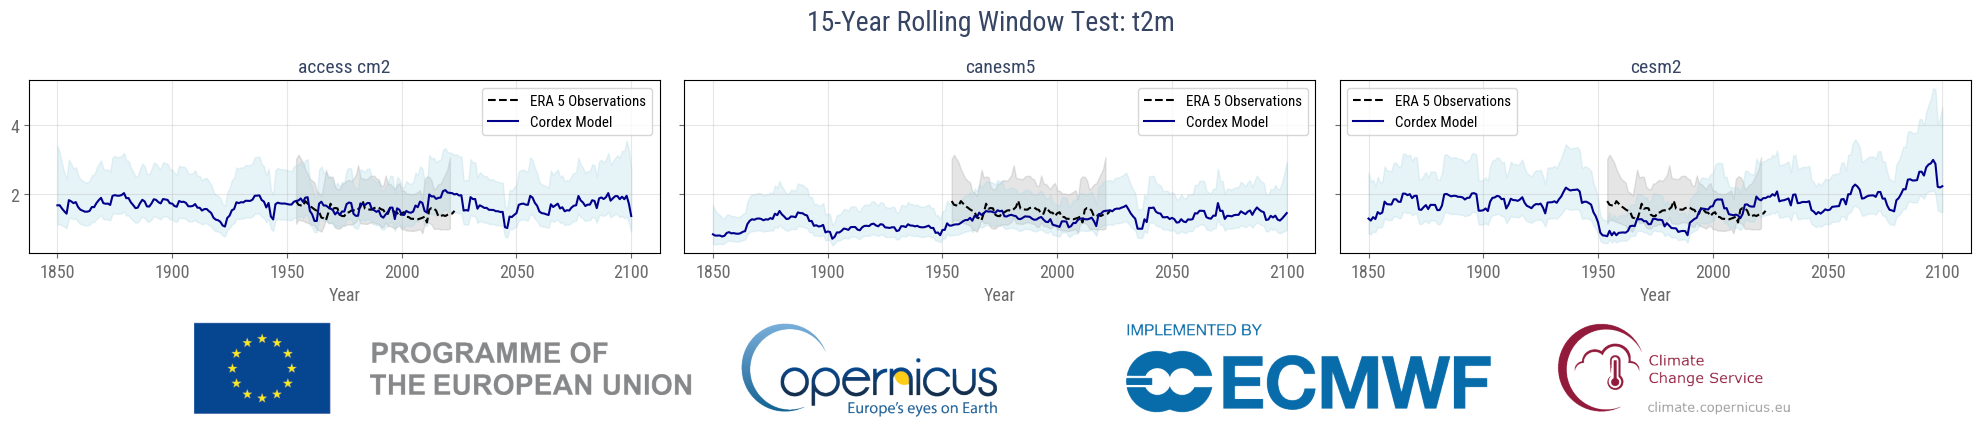

In [ ]:
print(f"Calculating 15-year rolling window test using method: {method}")
obs_ann_15ym = calculate_rolling_window_test(gdf=ts_ann_studyregion, value_col=value_col, datetime_col="year",
                                  window=15, method=method, min_periods=1, centering=True, ci=True)

cmip6_model_dfs_15ym = {}
cordex_model_dfs_15ym = {}
for name, df in cmip6_model_dfs.items():
    cmip6_model_dfs_15ym[name] = calculate_rolling_window_test(gdf=df, value_col='value', datetime_col="year",
                                  window=15, method=method, min_periods=1, centering=True, ci=True)
for name, df in cordex_model_dfs.items():
    cordex_model_dfs_15ym[name] = calculate_rolling_window_test(gdf=df, value_col='value', datetime_col="year",
                                  window=15, method=method, min_periods=1, centering=True, ci=True)
    

fig, axs, img_ax = Plot.plot_rolling_window_comparison(
     model_dfs=cordex_model_dfs_15ym, 
     obs_df=obs_ann_15ym, 
     value_col=value_col,
     legend_title=f"15-Year Rolling Window Test: {value_col}"
 )

fig, axs, img_ax = Plot.plot_rolling_window_comparison(
     model_dfs=cmip6_model_dfs_15ym, 
     obs_df=obs_ann_15ym, 
     value_col=value_col,
     legend_title=f"15-Year Rolling Window Test: {value_col}"
 )


### 4.6 Decide on which Models to Include

4.6	Decide on which models to include in the model synthesis. Note that if we have enough “good” models we can discuss whether we want to do the synthesis without including the "reasonable" models. If we still use the "reasonable" ones this should be noted as a caution in the associated text.
a.	If, per framing/model setup we have five or more models (from a different model ensemble) that are “good” according to the validation we do not use the “reasonable” models for that framing/model setup but only the “good” models. If we have less than five “good” models, first add only models with one “reasonable”, if still less than five models add models with two “reasonable” labels, etc.
b.	If we have two models stemming from the same model, e.g., a high and a lower resolution model, check (by eye) if the results in the attribution step are the same. If so, only use one of the models, otherwise keep both.
c.	In the scientific report the conclusion will appear in the table with values as ‘yes’ (good), ‘yes (just)’ (reasonable) or ‘no’ (bad).
d.	All decisions that deviate from the above points need to be documented including the reason of the decision.


CMIP6

In [107]:
# Convert yearly dataframes to R objects

cmip6_df_yearly_r = {}
cmip6_df_gmst_r = {}

for key, df in cmip6_model_dfs.items():
    with localconverter(ro.default_converter + pandas2ri.converter):
        cmip6_df_yearly_r[key] = ro.conversion.py2rpy(df)
        cmip6_df_gmst_r[key] = ro.conversion.py2rpy(cmip6_gmst_yearly[key])

cmip6_df_yearly_r = ListVector(cmip6_df_yearly_r)
ro.globalenv["cmip6_df_yearly_r"] = cmip6_df_yearly_r

cmip6_df_gmst_r = ListVector(cmip6_df_gmst_r)
ro.globalenv["cmip6_df_gmst_r"] = cmip6_df_gmst_r


In [108]:
%%R 

library(rwwa)
library(extRemes)

merge_model_gmst <- function(model_df, gmst_df) {
    
    # model_df has: time (POSIXct), value (tasmax)
    # gmst_df has: year, gmst
    # merge on year
    out <- merge(
        model_df[, c("year", "value")],
        gmst_df,
        by = "year",
        all = FALSE
    )
    
    return(out)
}


In [128]:
%%R

analyze_extreme_scenario <- function(model_name, model_df, gmst_df, 
                                     y_start, y_end, y_now, dGMST_target, 
                                     scenario_label, save_dir) {
    
    cat(paste0("   Scenario [", scenario_label, "]: Years ", y_start, "-", y_end, "\n"))
    
    # 1. Subset and Merge
    m_sub <- model_df[model_df$year >= y_start & model_df$year <= y_end, ]
    g_sub <- gmst_df[gmst_df$year >= y_start & gmst_df$year <= y_end, ]
    df <- merge_model_gmst(m_sub, g_sub)
    
    if (nrow(df) < 20) return(NULL)

    # 2. Fit Model
    mdl <- tryCatch({
        fit_ns(dist = "gev", type = "shift", data = df, 
               varnm = "value", covnm = "gmst", lower = F)
    }, error = function(e) return(NULL))

    if (is.null(mdl)) return(NULL)

    # 3. Define Covariates (CRITICAL FIX: drop=F keeps it as a DataFrame)
    # This prevents the "incorrect number of dimensions" error
    cov_now <- gmst_df[gmst_df$year == y_now, "gmst", drop = F]
    
    if (nrow(cov_now) == 0) {
        # Fallback: ensure it remains a 1-column dataframe
        val <- tail(df$gmst, 1)
        cov_now <- data.frame(gmst = val)
    }
    
    # Math on dataframes preserves the dataframe structure in R
    cov_hist <- cov_now - 1.3
    cov_fut  <- cov_now + dGMST_target

    # 4. Extract Results
    res <- tryCatch({
        cmodel_results(mdl, rp = 20, 
                       cov_f = cov_now, 
                       cov_hist = cov_hist, 
                       cov_fut = cov_fut, 
                       y_now = y_now, y_start = y_start, y_fut = y_end)
    }, error = function(e) {
        cat("      ❌ Extraction failed:", e$message, "\n")
        return(NULL)
    })

    if (!is.null(res)) {
        res_df <- as.data.frame((unlist(res)))
        
        # Add identifiers
        res_df$scenario <- scenario_label
        res_df$model <- model_name
        
        # 5. Plotting
        tryCatch({
            fname <- file.path(save_dir, paste0(model_name, "_", scenario_label, ".png"))
            val_to_plot <- unlist(res)[,"rp_value"]
            
            # Use 'cov_hist' (cov_cf) exactly like your original loop
            png(fname, width = 480, height = 360)
            plot_returnlevels(mdl, cov_f = cov_now, cov_cf = cov_hist, 
                              ev = val_to_plot, main = paste(model_name, scenario_label))
            dev.off()
        }, error = function(e) if (dev.cur() > 1) dev.off())
        
        return(res_df)
    }
    return(NULL)
}

In [129]:
%%R -i your_save_directory

# 1. Initialize List
all_scenarios_results <- list()
counter <- 1

# 2. Main Loop
for (name in names(cmip6_df_yearly_r)) {
    cat("Processing Model:", name, "\n")
    m_df <- cmip6_df_yearly_r[[name]]
    g_df <- cmip6_df_gmst_r[[name]]
    
    # Define the 4 scenarios
    scenarios <- list(
        list(ys=1950, ye=2025, yn=2025, dG=0,   lbl="Validation"),
        list(ys=1880, ye=2025, yn=2025, dG=0,   lbl="Past-Full"),
        list(ys=1880, ye=2100, yn=2025, dG=0.7, lbl="Future-2.0"),
        list(ys=1880, ye=2100, yn=2025, dG=1.3, lbl="Future-2.6")
    )
    
    # Run them
    for (s in scenarios) {
        res <- analyze_extreme_scenario(name, m_df, g_df, s$ys, s$ye, s$yn, s$dG, s$lbl, your_save_directory)
        if (!is.null(res)) {
            all_scenarios_results[[counter]] <- res
            counter <- counter + 1
        }
    }
}

# 3. Save to CSV (Corrected Logic)
cat("\nCombining results...\n")

if (length(all_scenarios_results) > 0) {
    
    # A. Simple Bind: 
    # Since 'res' is already a clean dataframe with 'model' and 'scenario' columns,
    # we just stack them. No lapply/transpose needed!
    df <- do.call(rbind, all_scenarios_results)

    # B. Add 'Include'
    df$Include <- TRUE

    # C. Reorder Columns for readability
    # We want Include, model, and scenario to be the FIRST 3 columns
    meta_cols <- c("Include", "model", "scenario")
    data_cols <- setdiff(names(df), meta_cols)
    
    # Combine them safely (ensuring we don't drop columns if names mismatch)
    df <- df[, c(meta_cols, data_cols)]

    # D. Save
    out_file <- file.path(your_save_directory, "res-models1.csv")
    write.csv(df, out_file, row.names = FALSE, quote = FALSE)
    
    cat("✅ Success! Saved results to:", out_file, "\n")
    cat("   (Columns reordered: Include -> model -> scenario -> ...)\n")
    
} else {
    cat("❌ No results generated.\n")
}

Processing Model: access_cm2 
   Scenario [Validation]: Years 1950-2025
   Scenario [Past-Full]: Years 1880-2025
   Scenario [Future-2.0]: Years 1880-2100
   Scenario [Future-2.6]: Years 1880-2100
Processing Model: canesm5 
   Scenario [Validation]: Years 1950-2025
   Scenario [Past-Full]: Years 1880-2025
   Scenario [Future-2.0]: Years 1880-2100
   Scenario [Future-2.6]: Years 1880-2100
Processing Model: cesm2 
   Scenario [Validation]: Years 1950-2025
   Scenario [Past-Full]: Years 1880-2025
   Scenario [Future-2.0]: Years 1880-2100
   Scenario [Future-2.6]: Years 1880-2100

Combining results...
<U+2705> Success! Saved results to: d:\Git\c3s-451\data/res-models1.csv 
   (Columns reordered: Include -> model -> scenario -> ...)


### 4.7 State other considerations for including or excluding models

### 4.8	Fill column “Include Y/N” for each model with the decision to include “Y” or exclude “N” the model.

---